# Train Next-Action Models With Category Feature

Notebook này sửa 3 vấn đề của pipeline cũ:

- label phải là **hành động kế tiếp**, không phải action cuối của chính input
- cột `category` phải được đưa vào feature train
- so sánh RNN, LSTM, biLSTM trên cùng một pipeline đúng


In [1]:
import os
import random

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Input, LSTM, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
MAX_LEN = 10

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


I0000 00:00:1777450108.942550  120813 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777450108.944819  120813 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777450110.898094  120813 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777450110.901242  120813 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv("data_user500.csv")
df.head()


,user_id,product_id,action,timestamp,category
0,1,4,view,2026-04-22 10:25:14.750782,Audio
1,1,18,click,2026-04-22 10:25:15.750782,Audio
2,1,18,add_to_cart,2026-04-22 10:25:16.750782,Audio
3,1,18,purchase,2026-04-22 10:25:17.750782,Audio
4,1,20,view,2026-04-22 10:31:14.750782,Audio


In [3]:
action_encoder = LabelEncoder()
category_encoder = LabelEncoder()

df["action_encoded"] = action_encoder.fit_transform(df["action"])
df["category_encoded"] = category_encoder.fit_transform(df["category"])

print("Action classes:", list(action_encoder.classes_))
print("Category classes:", list(category_encoder.classes_))
print("Action distribution:")
print(df["action"].value_counts(normalize=True).round(4))


Action classes: ['add_to_cart', 'click', 'purchase', 'remove_from_cart', 'review', 'search', 'view', 'wishlist']
Category classes: ['Accessories', 'Audio', 'Laptop', 'Monitor', 'Storage']
Action distribution:
action
view                0.2659
click               0.2329
purchase            0.1342
search              0.1139
add_to_cart         0.1010
wishlist            0.0653
remove_from_cart    0.0512
review              0.0355
Name: proportion, dtype: float64


In [4]:
action_sequences = []
category_sequences = []
labels = []

for _, group in df.groupby("user_id"):
    group = group.sort_values("timestamp")
    actions = group["action_encoded"].tolist()
    categories = group["category_encoded"].tolist()

    for i in range(1, len(group)):
        action_sequences.append(actions[:i])
        category_sequences.append(categories[:i])
        labels.append(actions[i])


In [5]:
X_action = pad_sequences(action_sequences, maxlen=MAX_LEN, padding="pre", truncating="pre")
X_category = pad_sequences(category_sequences, maxlen=MAX_LEN, padding="pre", truncating="pre")
X = np.stack([X_action, X_category], axis=-1).astype("float32")
y = np.array(labels, dtype="int32")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

majority_baseline = pd.Series(y_test).value_counts(normalize=True).max()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Majority baseline:", round(float(majority_baseline), 4))


X_train: (9933, 10, 2)
X_test: (2484, 10, 2)
Majority baseline: 0.2536


In [6]:
def build_model(kind, input_shape=(MAX_LEN, 2), num_classes=len(action_encoder.classes_)):
    if kind == "RNN":
        backbone = SimpleRNN(64)
    elif kind == "LSTM":
        backbone = LSTM(64)
    elif kind == "biLSTM":
        backbone = Bidirectional(LSTM(64))
    else:
        raise ValueError(f"Unsupported model kind: {kind}")

    model = Sequential([
        Input(shape=input_shape),
        backbone,
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"],
    )
    return model


In [7]:
callbacks = [EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
models = {}
histories = {}

for kind in ["RNN", "LSTM", "biLSTM"]:
    model = build_model(kind)
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=12,
        batch_size=32,
        callbacks=callbacks,
        verbose=1,
    )
    models[kind] = model
    histories[kind] = history


Epoch 1/12
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5188 - loss: 1.2349 - val_accuracy: 0.6208 - val_loss: 0.9220
Epoch 2/12
311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6127 - loss: 0.8904 - val_accuracy: 0.6643 - val_loss: 0.7643
Epoch 3/12
311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6427 - loss: 0.7848 - val_accuracy: 0.7053 - val_loss: 0.6858
Epoch 4/12
311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6763 - loss: 0.7126 - val_accuracy: 0.7093 - val_loss: 0.6387
Epoch 5/12
311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6912 - loss: 0.6730 - val_accuracy: 0.7142 - val_loss: 0.6083
Epoch 6/12
311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6978 - loss: 0.6441 - val_accuracy: 0.7174 - val_loss: 0.5885
Epoch 7/12
311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7086 - loss: 0.6181 - val_accuracy: 0.7150 - val_loss: 0.5838
Epoch 8/12
311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7111 - loss: 0.6094 - val_accuracy: 0.

In [8]:
results = {}
for kind, model in models.items():
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    results[kind] = {
        "best_val_accuracy": float(max(histories[kind].history["val_accuracy"])),
        "test_accuracy": float(test_acc),
    }

results


{'RNN': {'best_val_accuracy': 0.7363123893737793,
  'test_accuracy': 0.7363123893737793},
 'LSTM': {'best_val_accuracy': 0.7105475068092346,
  'test_accuracy': 0.5418679714202881},
 'biLSTM': {'best_val_accuracy': 0.7008856534957886,
  'test_accuracy': 0.5515297651290894}}

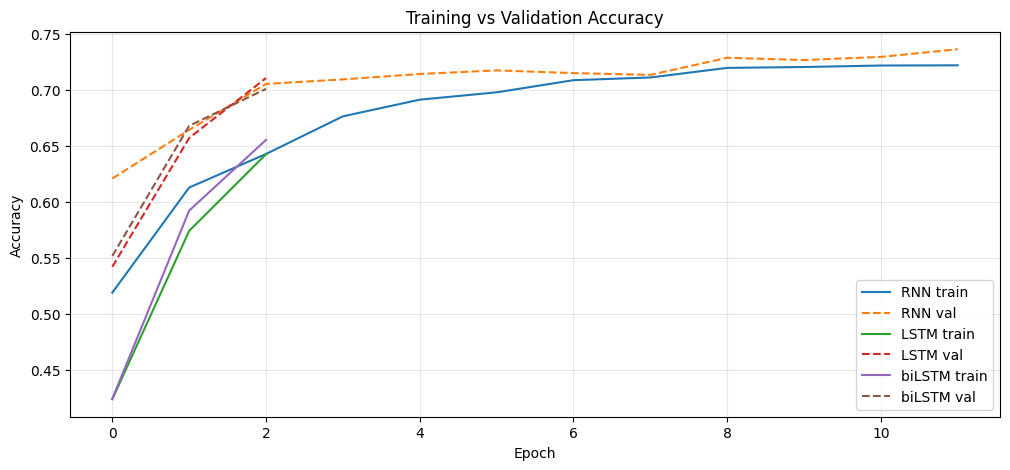

In [9]:
plt.figure(figsize=(12, 5))
for kind, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{kind} train")
    plt.plot(history.history["val_accuracy"], linestyle="--", label=f"{kind} val")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


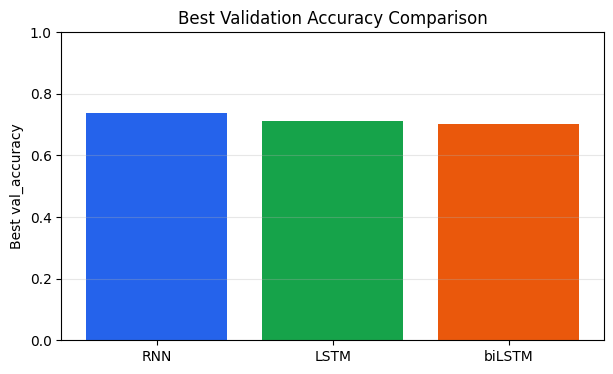

In [10]:
best_scores = {kind: metric["best_val_accuracy"] for kind, metric in results.items()}

plt.figure(figsize=(7, 4))
plt.bar(best_scores.keys(), best_scores.values(), color=["#2563eb", "#16a34a", "#ea580c"])
plt.title("Best Validation Accuracy Comparison")
plt.ylabel("Best val_accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()


In [11]:
models["RNN"].save("model_rnn.h5")
models["LSTM"].save("model_lstm.h5")
models["biLSTM"].save("model_bilstm.h5")
